M2: mu ~ N(3, I), y|mu ~ N(mu, I)
with MMD summary space regularization
D=20, N=10, S=2D

In [1]:
import numpy as np
import bayesflow as bf
import keras
from pathlib import Path

INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/anaconda3/envs/benchmark2/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/local/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)
INFO:bayesflow:Using backend 'jax'


In [2]:
from tqdm.auto import tqdm as original_tqdm
import bayesflow.approximators.helpers.samplers as bf_samplers
import bayesflow.approximators.helpers.conditions as bf_conditions

def quiet_tqdm(*args, **kwargs):
    kwargs["disable"] = True
    return original_tqdm(*args, **kwargs)

bf_samplers.tqdm = quiet_tqdm
bf_conditions.tqdm = quiet_tqdm


In [3]:
RNG=np.random.default_rng(2025)
num_dims=20
num_obs=10
mu_prior_mean=3
mu_prior_std=1
likelihood_std=1

In [4]:
# simulator
def prior(mu=mu_prior_mean, sigma=mu_prior_std):
    mu = RNG.normal(loc=mu, scale=sigma, size=num_dims)
    return dict(mu=mu)
def likelihood(mu):
    x =RNG.normal(loc=mu, scale=likelihood_std, size=(num_obs, num_dims))
    return dict(x=x)
simulator=bf.make_simulator([prior,likelihood])

In [5]:
# adapter 
adapter = (bf.adapters.Adapter()
                        .convert_dtype("float64", "float32")
                        .rename('mu', 'inference_variables')
                        .rename('x', 'summary_variables')
                )

In [6]:
# networks
summary_net = bf.networks.DeepSet(
    summary_dim=2*num_dims, base_distribution="normal"
)

inference_net = bf.networks.CouplingFlow(depth=8,
                                         subnet_kwargs={"widths":(256,256,256),
                                                        "norm": "layer",},
                                                        )

In [7]:
workflow = bf.BasicWorkflow(simulator=simulator,
                                          adapter=adapter,
                                          summary_network=summary_net,
                                          inference_network=inference_net,
                                          standardize="all"
                                          )
epochs=256
batch_size=64
num_batches_per_epoch=128
learning_rate=keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=1e-4, 
            decay_steps=epochs * num_batches_per_epoch
            )
workflow.approximator.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate))

In [8]:
history = workflow.fit_online(epochs=epochs,batch_size=batch_size,num_batches_per_epoch=num_batches_per_epoch)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/256
128/128 ━━━━━━━━━━━━━━━━━━━━ 41s 78ms/step - loss: 21.9901 - loss/inference_loss: 21.6895 - loss/summary_loss: 0.3006
Epoch 2/256
128/128 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - loss: 18.5985 - loss/inference_loss: 18.2981 - loss/summary_loss: 0.3003
Epoch 3/256
128/128 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - loss: 16.5107 - loss/inference_loss: 16.1977 - loss/summary_loss: 0.3130
Epoch 4/256
128/128 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - loss: 15.2020 - loss/inference_loss: 14.8754 - loss/summary_loss: 0.3266
Epoch 5/256
128/128 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - loss: 14.3148 - loss/inference_loss: 13.9816 - loss/summary_loss: 0.3332
Epoch 6/256
128/128 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - loss: 13.8028 - loss/inference_loss: 13.4555 - loss/summary_loss: 0.3473
Epoch 7/256
128/128 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - loss: 11.9917 - loss/inference_loss: 11.6334 - loss/summary_loss: 0.3582
Epoch 8/256
128/128 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - loss: 11.0949 - loss/inference_loss: 10

INFO:bayesflow:Training completed in 40.08 minutes.


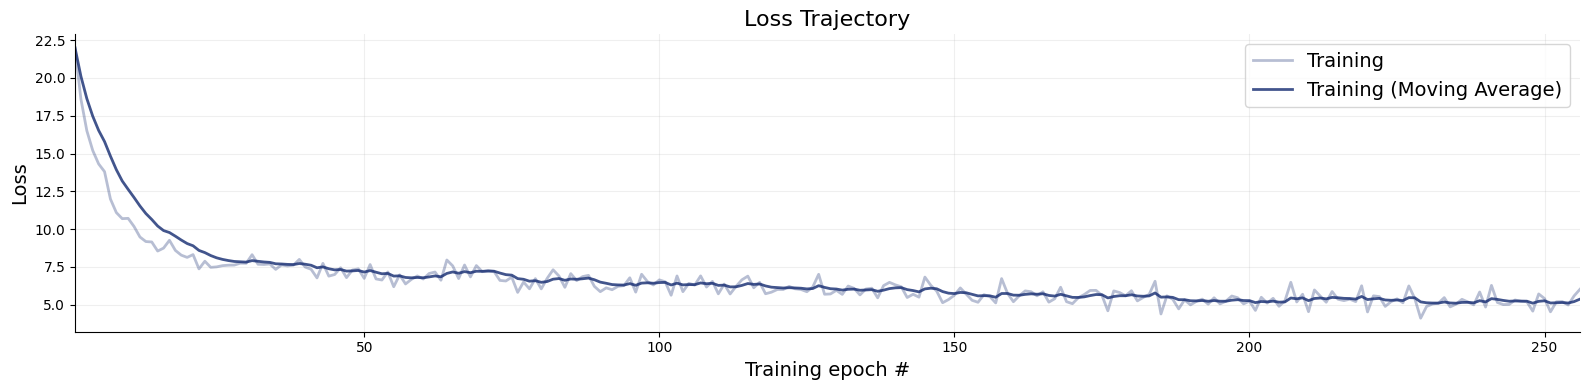

In [9]:
f=bf.diagnostics.plots.loss(history)

In [10]:
# Generate test datasets and get posterior samples and perform diagnostics
num_samples = 1000 #number of posterior samples
val_sims = simulator.sample(200) # validation data
post_draws = workflow.sample(conditions=val_sims, num_samples=num_samples)
post_draws.keys()


INFO:bayesflow:Sampling completed in 9.69 seconds.


dict_keys(['mu'])

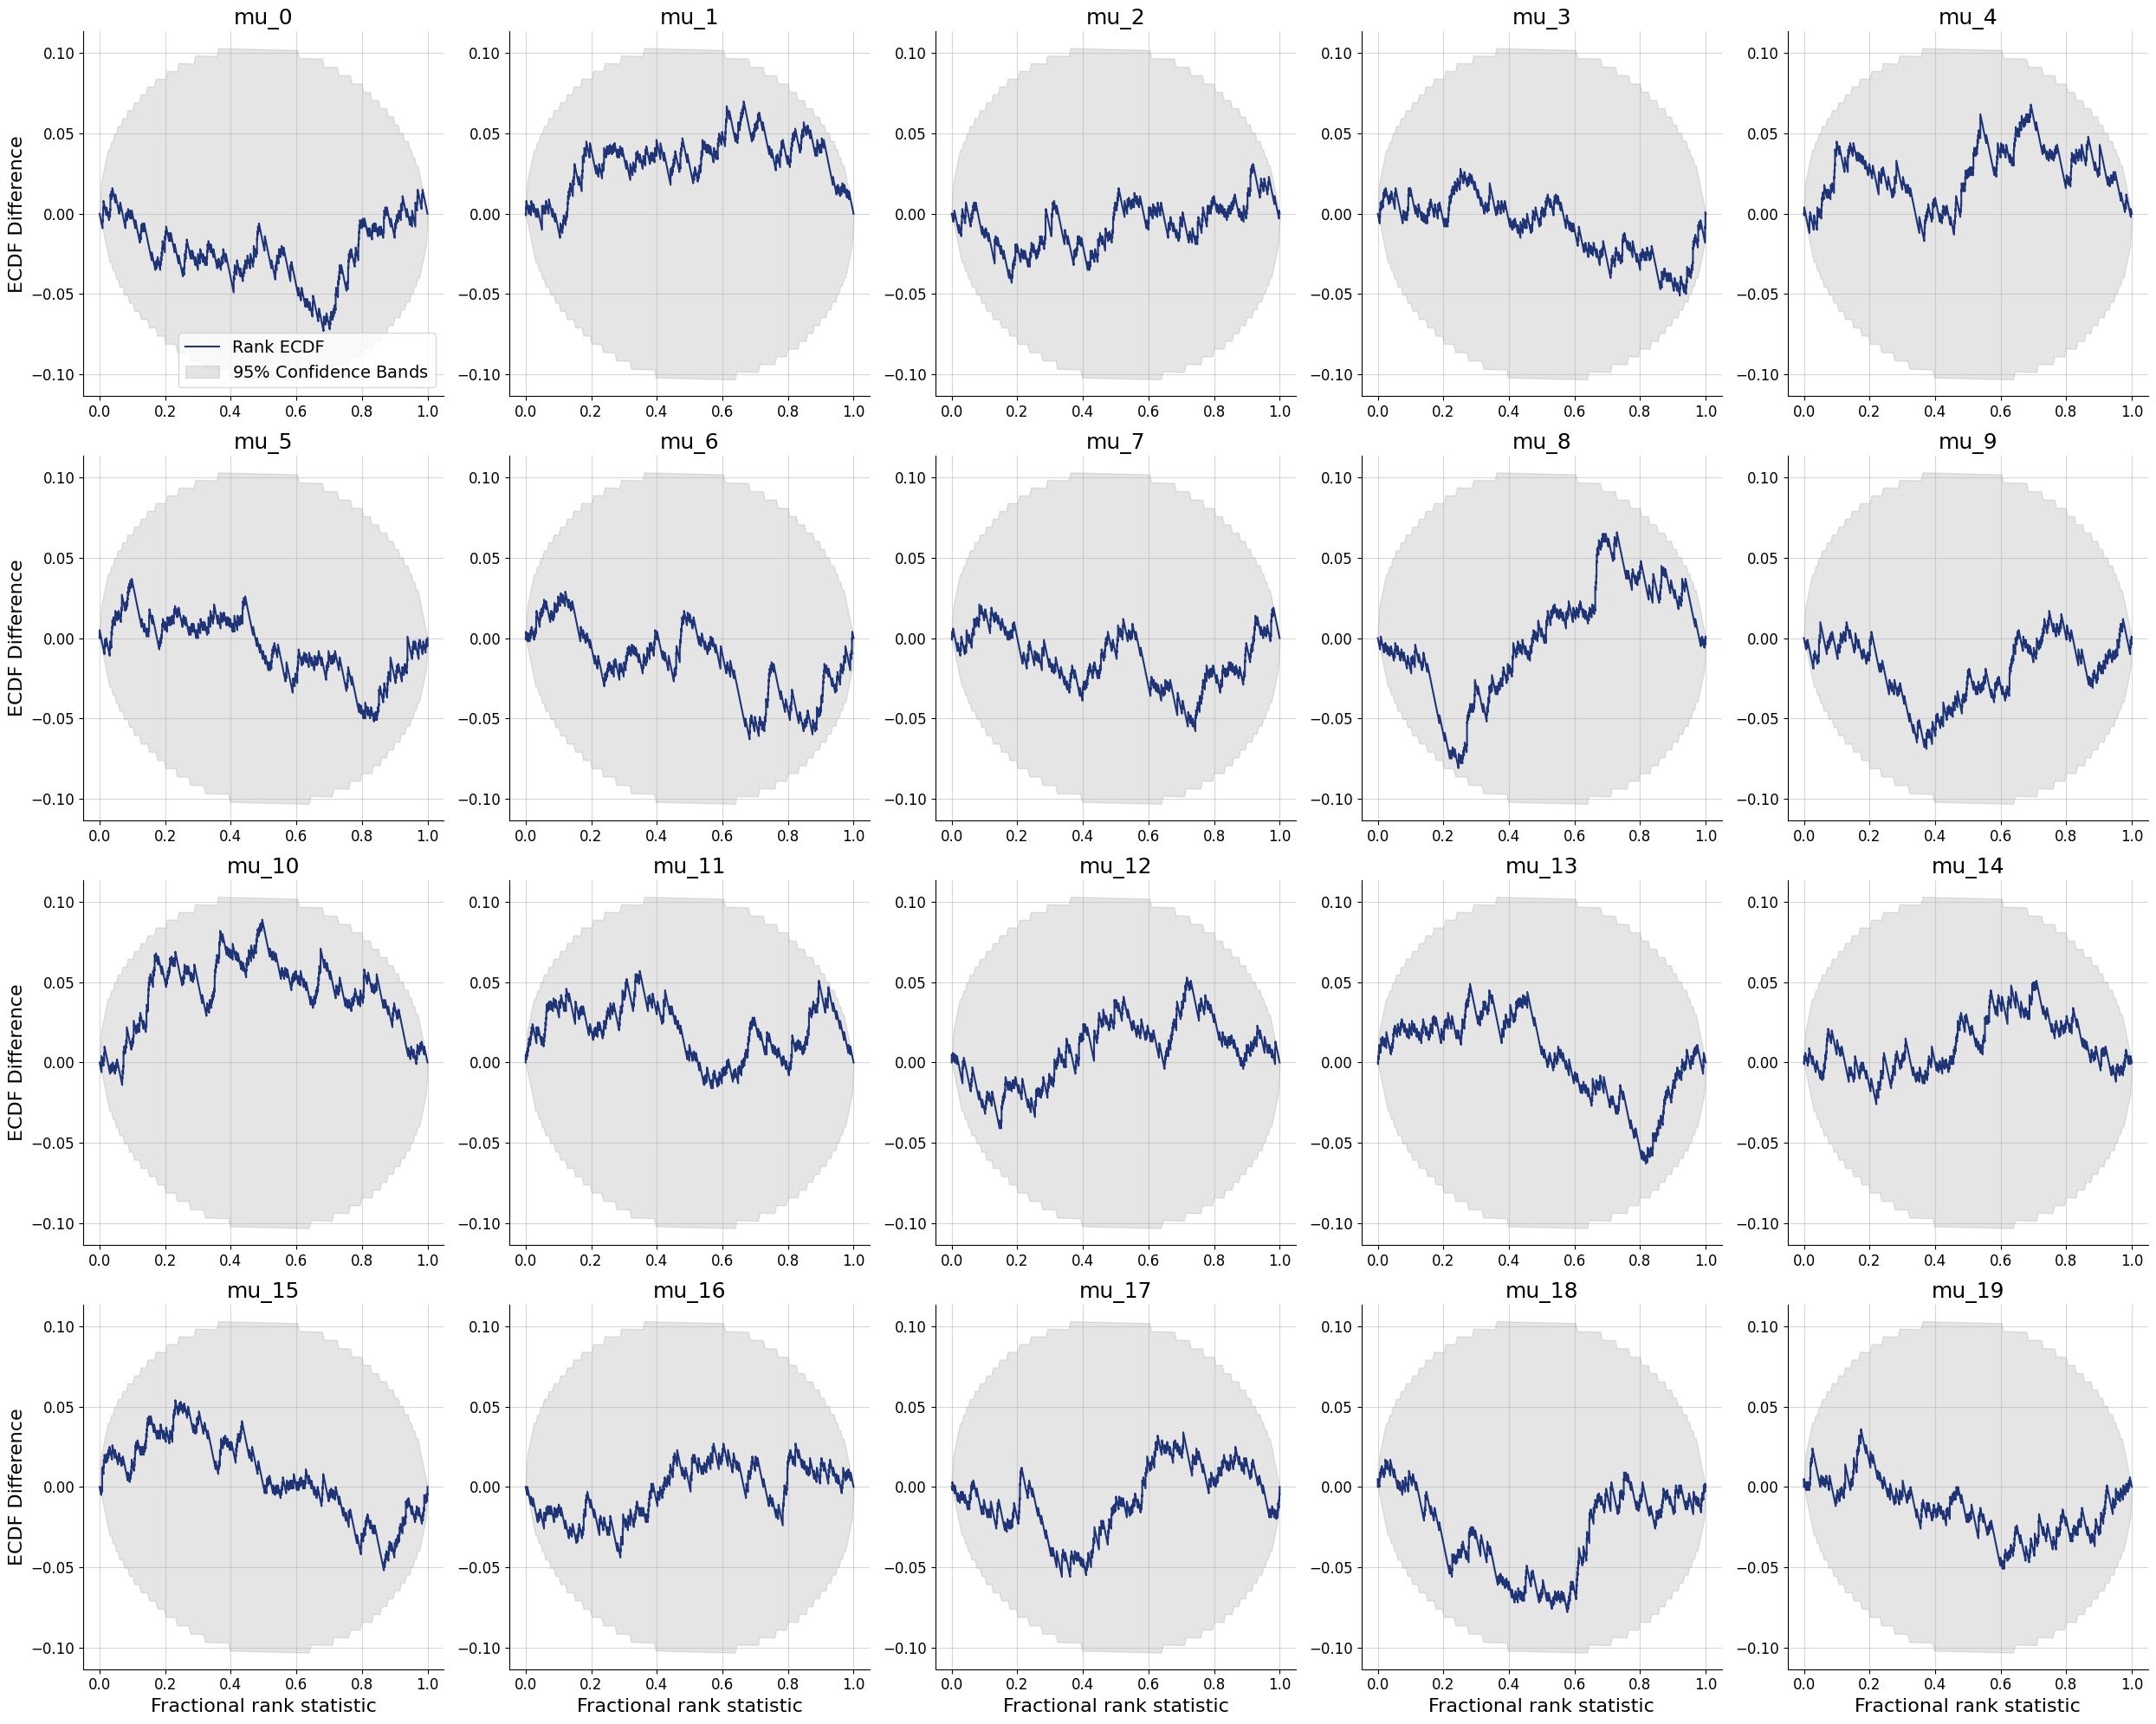

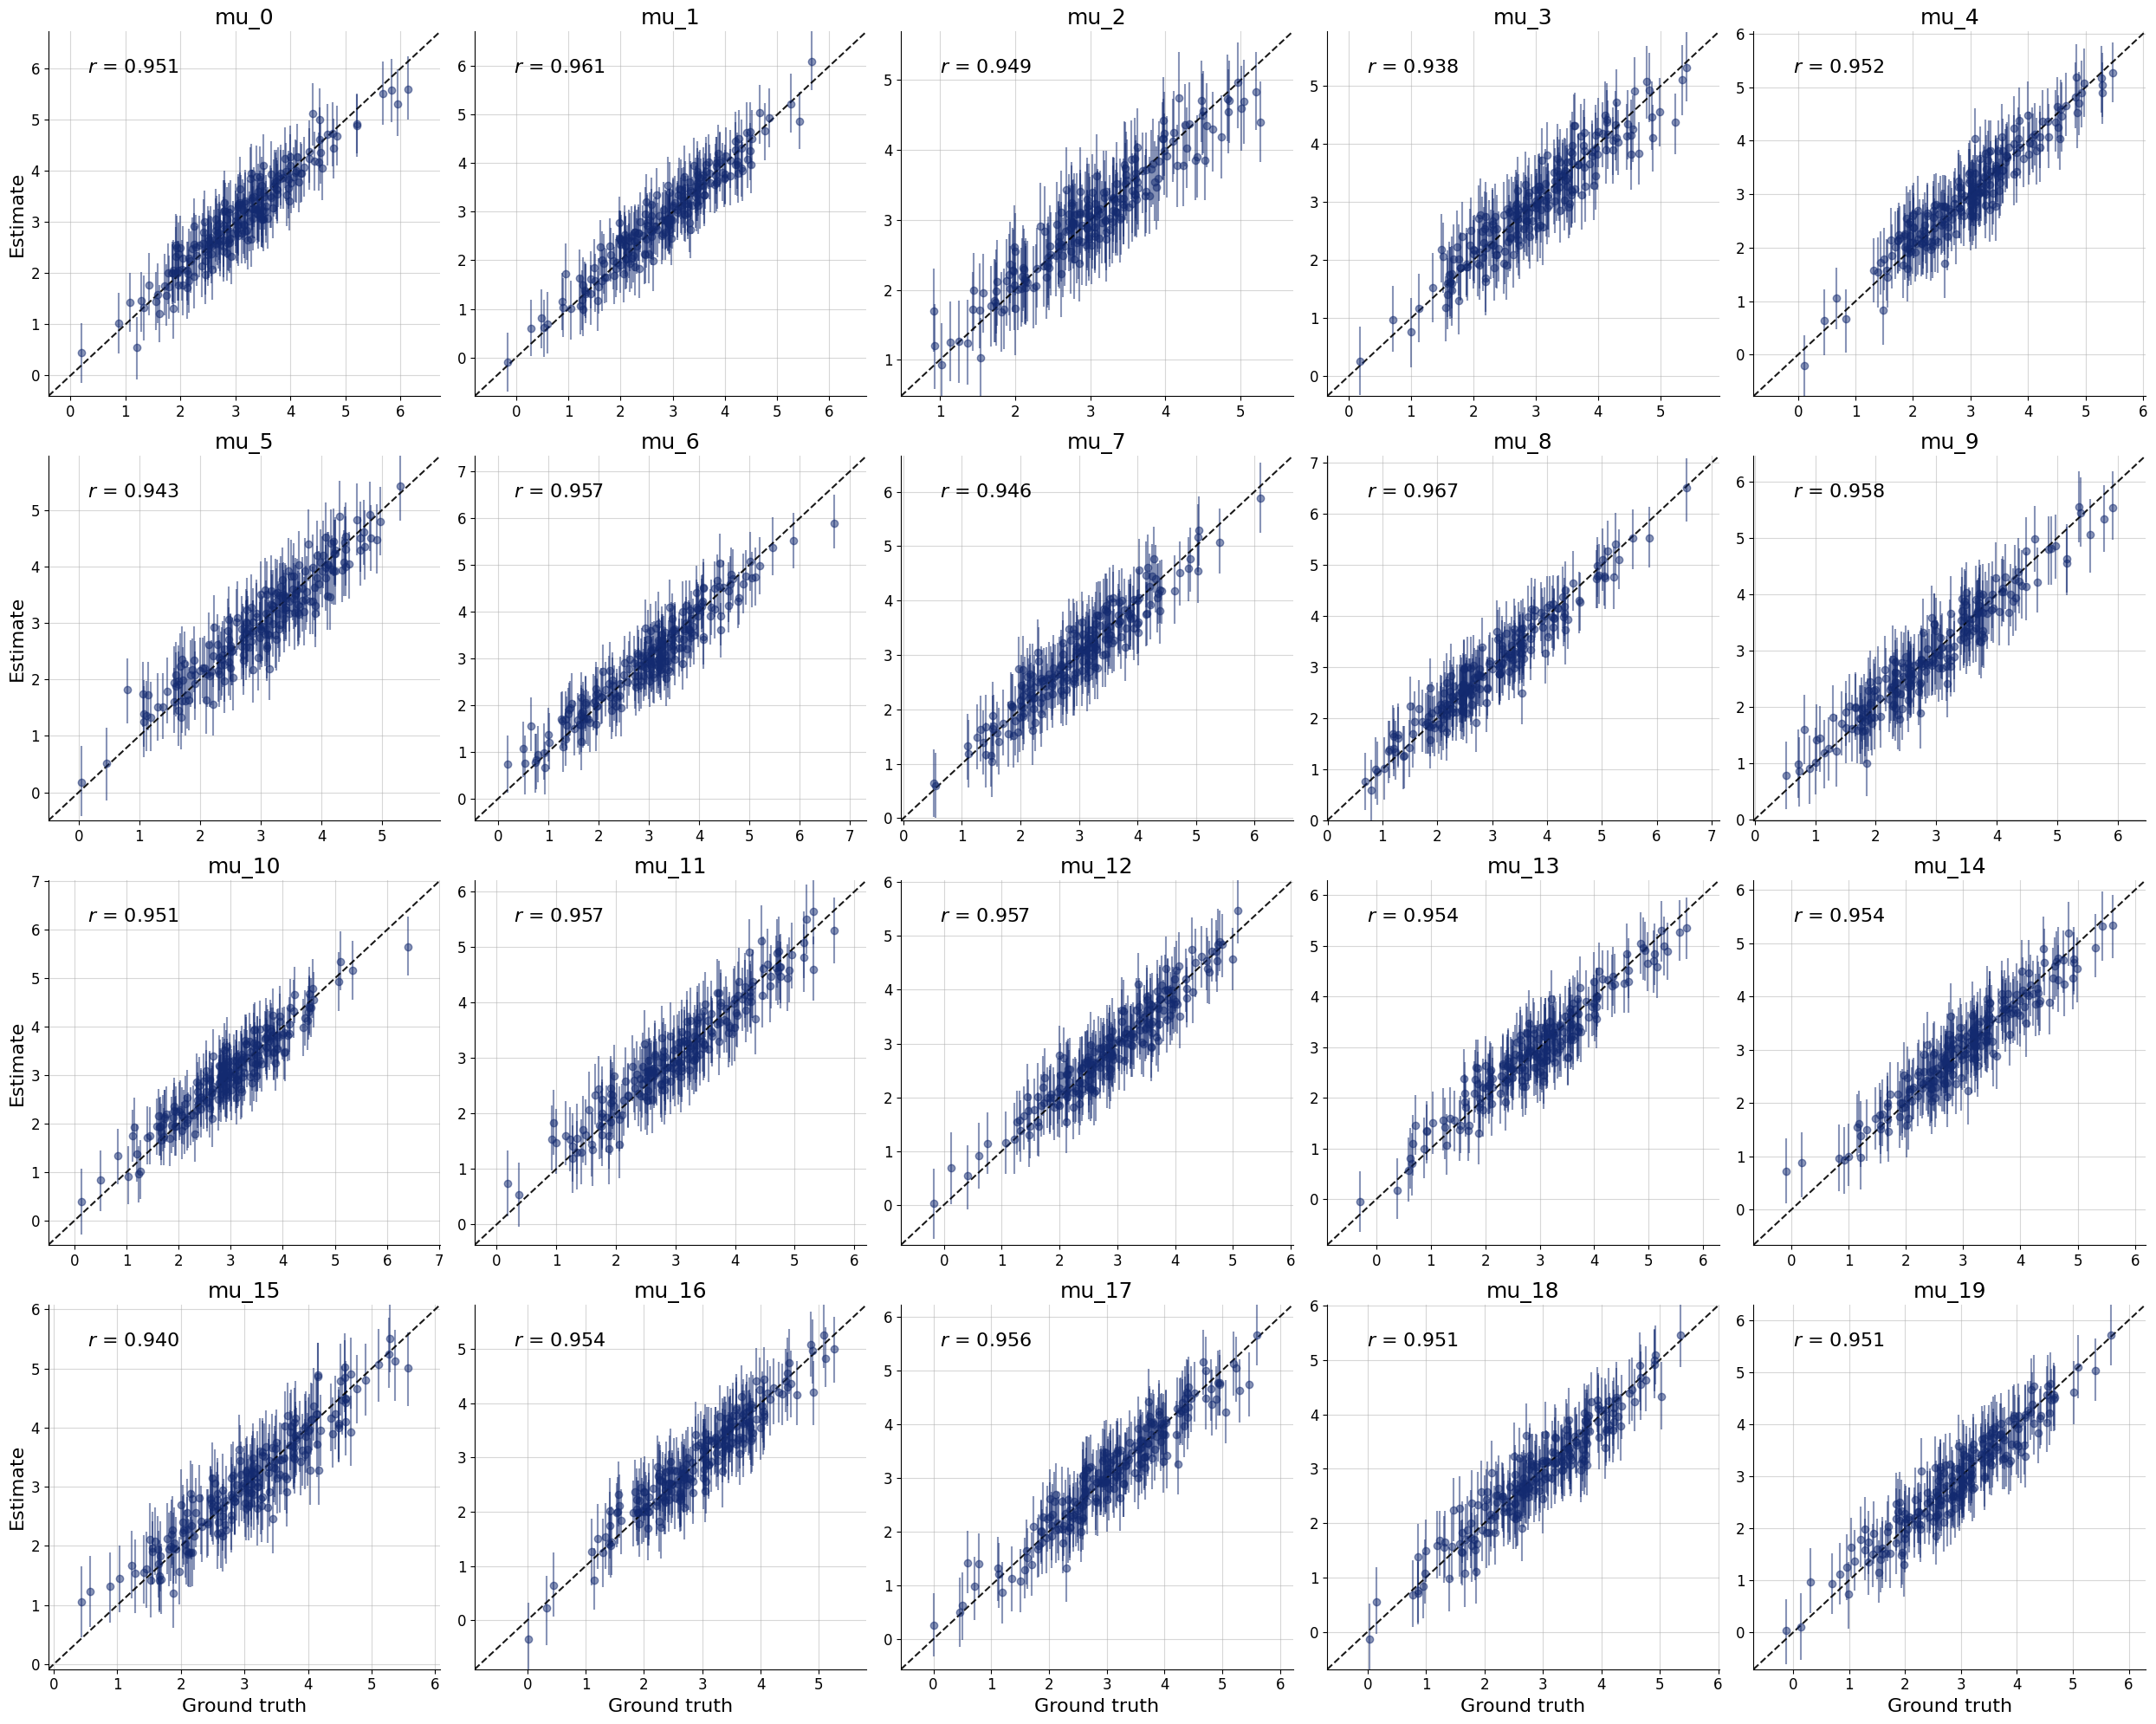

In [11]:
# f1 = bf.diagnostics.plots.calibration_histogram(post_draws, val_sims)
f2 = bf.diagnostics.plots.calibration_ecdf(post_draws, val_sims,difference=True)
f3 = bf.diagnostics.plots.recovery(post_draws, val_sims)

In [12]:
# Save the trained approximator
filepath = Path("/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian/networks") / "m2_s_40d_10n.keras"
filepath.parent.mkdir(exist_ok=True)
workflow.approximator.save(filepath=filepath)

In [13]:
# load approximator
filepath = Path("/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian/networks") / "m2_s_40d_10n.keras"
approximator = keras.saving.load_model(filepath)

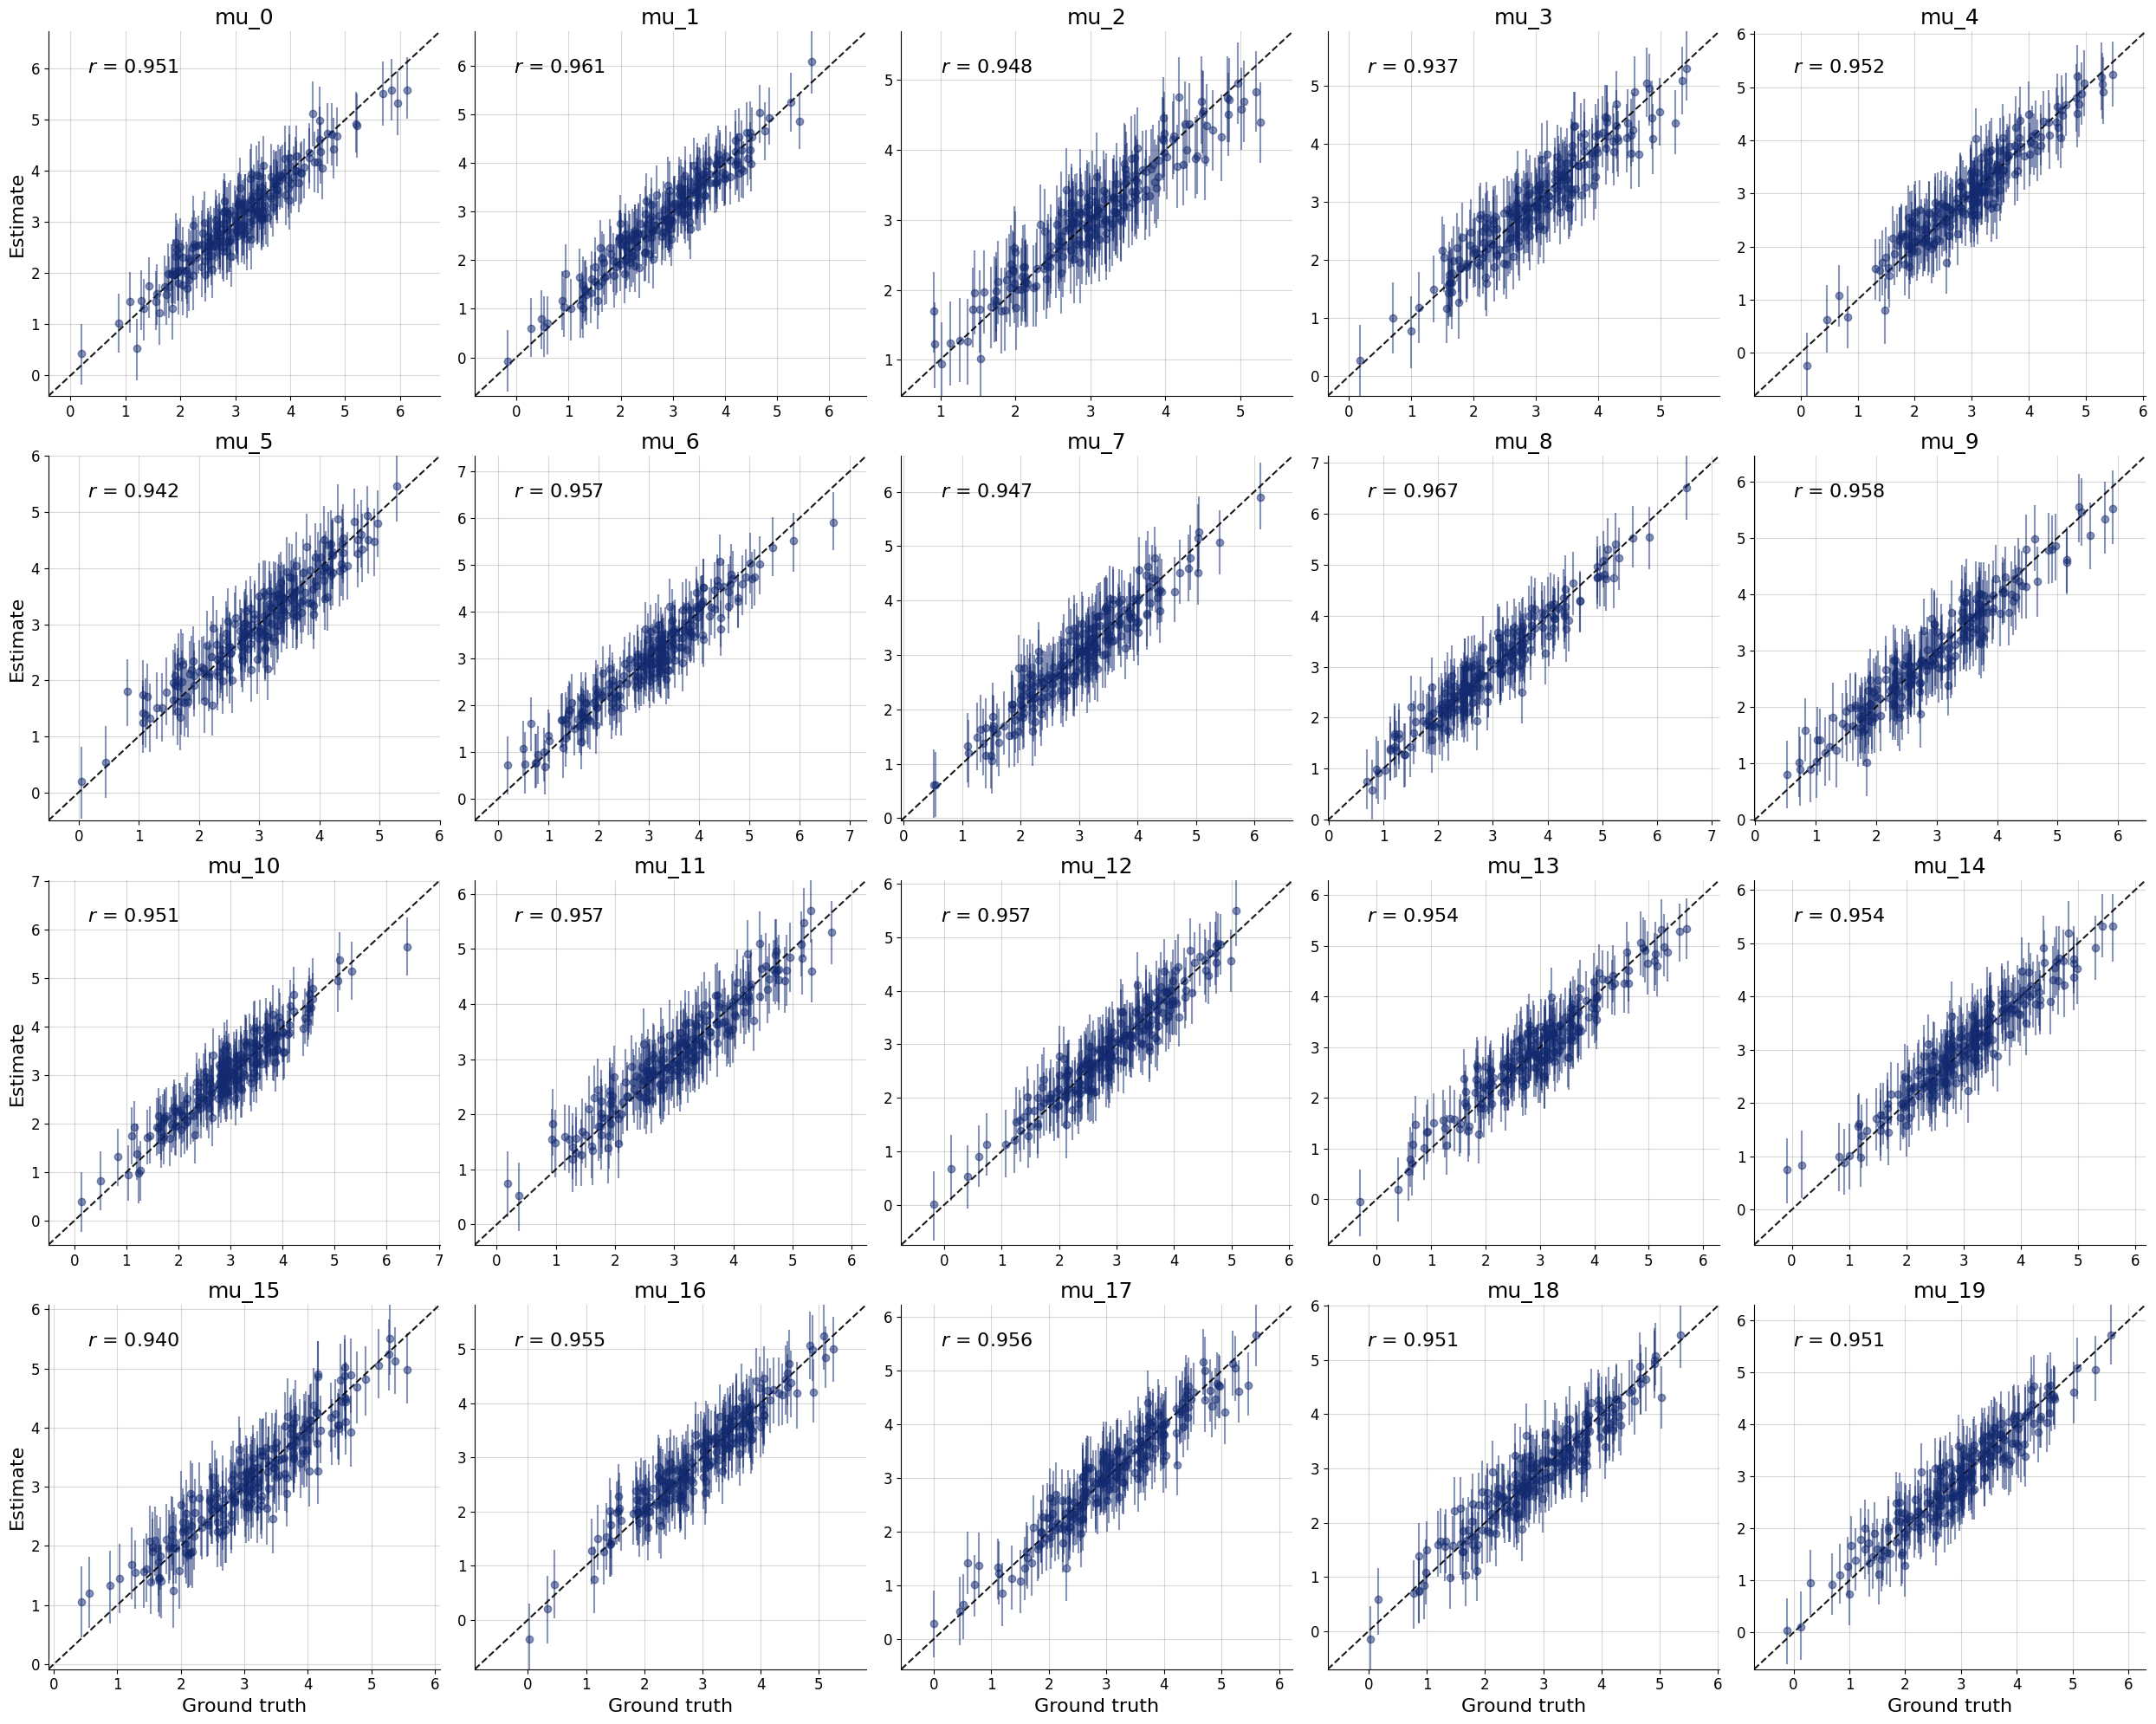

In [14]:
post_draws = approximator.sample(conditions=val_sims, num_samples=num_samples)
f3 = bf.diagnostics.plots.recovery(post_draws, val_sims)